In [39]:
import pandas as pd

df = pd.read_csv('/content/sample_data/select_crop_df.csv')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   expected_start_date    872 non-null    object 
 1   commitment_date        917 non-null    object 
 2   agency_name            917 non-null    object 
 3   usd_commitment_defl    917 non-null    float64
 4   donor_code             917 non-null    int64  
 5   region_code            917 non-null    int64  
 6   de_recipientcode       917 non-null    object 
 7   donor_name             917 non-null    object 
 8   year                   917 non-null    int64  
 9   initial_report         917 non-null    int64  
 10  ld_cflag               0 non-null      float64
 11  short_description      917 non-null    object 
 12  region_name            917 non-null    object 
 13  usd_disbursement       917 non-null    float64
 14  usd_disbursement_defl  917 non-null    float64
 15  financ

In [40]:
df.head(50)[['year','expected_start_date','project_title','geography','found_crops_short','found_crops_long','long_description','short_description','recipient_name','project_number']].sort_values("expected_start_date")

,year,expected_start_date,project_title,geography,found_crops_short,found_crops_long,long_description,short_description,recipient_name,project_number
49,2009,2006-11-01,International Development Enterprises,Zambia,[],['fruit'],"to develop small-plot water technologies, tech...",INTERNATIONAL DEVELOPMENT ENTERPRISES,Zambia,OPP45235
48,2009,2006-11-01,International Development Enterprises,Ethiopia,[],['fruit'],"to develop small-plot water technologies, tech...",INTERNATIONAL DEVELOPMENT ENTERPRISES,Ethiopia,OPP45235
2,2009,2008-09-01,Donald Danforth Plant Science Center,South Africa,[],['cassava'],to develop cassava germplasm enriched with bio...,DONALD DANFORTH PLANT SCIENCE CENTER,South Africa,OPP37880_01
12,2009,2009-07-27,International Crops Research Institute for the...,United Republic of Tanzania,[],['sorghum'],to boost the incomes of small-holder farmers i...,INTERNATIONAL CROPS RESEARCH INSTITUTE FOR THE...,Tanzania,OPP51880
11,2009,2009-07-27,International Crops Research Institute for the...,United Republic of Tanzania,[],['sorghum'],to boost the incomes of small-holder farmers i...,INTERNATIONAL CROPS RESEARCH INSTITUTE FOR THE...,Tanzania,OPP51880
10,2009,2009-07-27,International Crops Research Institute for the...,Sudan,[],['sorghum'],to boost the incomes of small-holder farmers i...,INTERNATIONAL CROPS RESEARCH INSTITUTE FOR THE...,Sudan,OPP51880
9,2009,2009-07-27,International Crops Research Institute for the...,Sudan,[],['sorghum'],to boost the incomes of small-holder farmers i...,INTERNATIONAL CROPS RESEARCH INSTITUTE FOR THE...,Sudan,OPP51880
8,2009,2009-07-27,International Crops Research Institute for the...,Eritrea,[],['sorghum'],to boost the incomes of small-holder farmers i...,INTERNATIONAL CROPS RESEARCH INSTITUTE FOR THE...,Eritrea,OPP51880
6,2009,2009-07-27,International Crops Research Institute for the...,Nigeria,[],['sorghum'],to boost the incomes of small-holder farmers i...,INTERNATIONAL CROPS RESEARCH INSTITUTE FOR THE...,Nigeria,OPP51880
5,2009,2009-07-27,International Crops Research Institute for the...,Nigeria,[],['sorghum'],to boost the incomes of small-holder farmers i...,INTERNATIONAL CROPS RESEARCH INSTITUTE FOR THE...,Nigeria,OPP51880


In [41]:
df.long_description.nunique()

271

In [42]:
unique_descriptions = df['long_description'].unique()
for desc in unique_descriptions:
  print("--------")
  print(desc)
  print("--------")


--------
to improve the nutritional status in Uganda and surrounding countries through the generation of farmer and consumer acceptable edible bananas with significantly increased fruit levels of pro-vitamin A and iron
--------
--------
to develop cassava germplasm enriched with bioavailable nutrients
--------
--------
to provide loans and financial training to small and growing rural businesses in Africa
--------
--------
to boost the incomes of small-holder farmers in moisture-deficient areas of Sub-Saharan Africa and South Asia by increasing their yields of sorghum, pearl millet, and finger millet
--------
--------
to develop a next-generation platform to identify cassava molecular markers for crop improvement
--------
--------
to support increasing skills in cereal rust pathology and genetics in the developing world
--------
--------
to produce high-yielding, stress-tolerant varieties of sweet potato to help farming families in Sub-Saharan Africa improve their productivity, incomes

In [43]:
import ast
import re
import pandas as pd
import numpy as np

crop_name_map = {
    "Banana": ["banana", "bananas", "cooking banana", "cooking bananas",
               "East African Highland Banana", "East African Highland Bananas",
               "wild bananas", "wild banana"],
    "Plantain": ["banana-plantain", "plantain", "plantains"],
    "Enset": ["enset banana", "enset"],
    "Cassava": ["cassava"],
    "Sorghum": ["sorghum"],
    "Pearl millet": ["pearl millet"],
    "Finger millet": ["finger millet"],
    "Millet (general/unspecified)": ["millet", "millets"],
    "Sweet potato": ["sweet potato", "sweet potatoes", "sweetpotato", "sweetpotatoes",
                      "orange-fleshed sweet potato", "orange-fleshed sweetpotato", "OFSP"],
    "Mango": ["mangoes", "mango"],
    "Passion fruit": ["passion fruits", "passion fruit"],
    "Yam": ["yam", "yams"],
    "Rice": ["rice"],
    "Maize": ["maize"],
    "Wheat": ["wheat"],
    "Cowpea": ["cowpea", "cowpea grain"],
    "Cotton": ["cotton"],
    "Common bean": ["bean", "beans"],
    "Winter melon": ["winter melon"],
    "Coffee": ["coffee"],
    "Paprika": ["paprika"],
    "Cashew": ["cashew", "cashew trees", "cashew nut"],
    "Potato": ["potato", "potatoes"],
    "Oil palm": ["palm oil", "Fresh Fruit Bunches (FFB)", "FFB"],
    "Soybean": ["soybean", "Soyabean"],
    "Tomato": ["tomato"],
    "Onion": ["onion"],
    "Avocado": ["avocado"],
    "Chili pepper": ["chili pepper", "chilli pepper"],
    "Green bean": ["green bean"],
}

crop_group_map = {
    "Cereals": ["cereal", "cereals", "cereal crop", "cereal crops", "dryland cereals"],
    "Grain legumes": ["grain legume", "grain legumes", "tropical grain legume",
                       "legume", "legumes", "pulses", "pulse/grain legume"],
    "Roots, Tubers & Bananas (RTB)": ["roots, tubers, and bananas (RTB)", "RTB"],
    "Roots and Tubers": ["root and tuber crops", "root/tuber crop", "root and tuber crop", "roots", "tubers", "root", "tuber"],
    "Nutri-cereals": ["nutri-cereals"],
    "Wholegrains": ["whole grains", "wholegrain", "Fortified Wholegrain Alliance"],
    "Fruits & vegetables": ["fruit and vegetable", "fruits and vegetables"],
    "Grains (general)": ["grain", "grains"],
}

non_crop_products = {
    "Dairy": ["dairy", "milk", "butter", "cheese", "fruit yoghurt"],
    "Honey/Apiculture": ["honey", "apiculture"],
    "Poultry": ["poultry"],
    "Tilapia (aquaculture)": ["tilapia"],
    "Bovine tuberculosis (livestock health)": ["bovine tuberculosis"],
}

def extract_mentions_from_text(text, mention_map):
    """Extracts categories from text based on a provided mention map, prioritizing longer keyword matches and using word boundaries.
    If 'Sweet potato' is found, 'Potato' is explicitly not added."""
    if pd.isna(text):
        return []
    text_lower = str(text).lower()
    found_categories = set()

    sweet_potato_found = False
    # Step 1: Check for 'Sweet potato' first
    for keyword in mention_map.get('Sweet potato', []):
        if re.search(r'\b' + re.escape(keyword.lower()) + r'\b', text_lower):
            found_categories.add('Sweet potato')
            sweet_potato_found = True
            break # Found Sweet potato, no need to check other keywords for Sweet potato

    # Step 2: If Sweet potato was NOT found, then check for 'Potato'
    # This ensures that 'Potato' is not added if 'Sweet potato' is already present.
    if not sweet_potato_found:
        for keyword in mention_map.get('Potato', []):
            if re.search(r'\b' + re.escape(keyword.lower()) + r'\b', text_lower):
                found_categories.add('Potato')
                break # Found Potato, no need to check other keywords for Potato

    # Step 3: Process all other categories, excluding Sweet potato and Potato as they are handled
    other_mention_map = {k: v for k, v in mention_map.items() if k not in ['Sweet potato', 'Potato']}

    all_keyword_category_pairs = []
    for category, keywords in other_mention_map.items():
        for keyword in keywords:
            all_keyword_category_pairs.append((keyword.lower(), category))

    # Sort the pairs by keyword length in descending order for general processing
    all_keyword_category_pairs.sort(key=lambda x: len(x[0]), reverse=True)

    for keyword, category in all_keyword_category_pairs:
        if re.search(r'\b' + re.escape(keyword) + r'\b', text_lower):
            found_categories.add(category)

    return sorted(list(found_categories))

def parse_found_crops_column(x):
    # If it's already a list, return it as is
    if isinstance(x, list):
        return x
    # If it's NaN, return an empty list
    if pd.isna(x):
        return []
    # If it's a string, try to evaluate it as a list, otherwise wrap it
    if isinstance(x, str):
        cleaned_x = x.strip()
        if cleaned_x.startswith('[') and cleaned_x.endswith(']') and len(cleaned_x) > 2:
            try:
                evaluated = ast.literal_eval(cleaned_x)
                if isinstance(evaluated, list):
                    return evaluated
                else:
                    return [evaluated]
            except (ValueError, SyntaxError):
                return [cleaned_x]
        else:
            return [cleaned_x]
    # For any other scalar type, wrap it in a list
    return [x]

# Ensure 'found_crops_short', 'found_crops_long', 'found_crops' are parsed as lists
for col in ['found_crops_short', 'found_crops_long', 'found_crops']:
    df[col] = df[col].apply(parse_found_crops_column)


# Create new columns for mentions
df['normalized_crop_mentions'] = df['long_description'].apply(lambda x: extract_mentions_from_text(x, crop_name_map))
df['crop_group_mentions'] = df['long_description'].apply(lambda x: extract_mentions_from_text(x, crop_group_map))
df['non_crop_mentions'] = df['long_description'].apply(lambda x: extract_mentions_from_text(x, non_crop_products))

# Combine all agricultural product mentions
def combine_all_mentions(row):
    combined = set()
    combined.update(row['normalized_crop_mentions'])
    combined.update(row['crop_group_mentions'])
    combined.update(row['non_crop_mentions'])
    return sorted(list(combined))

df['combined_agri_products'] = df.apply(combine_all_mentions, axis=1)

# Display the first few rows with the new columns
display(df[['long_description', 'short_description', 'found_crops_short', 'normalized_crop_mentions', 'crop_group_mentions', 'non_crop_mentions', 'combined_agri_products']].head())

,long_description,short_description,found_crops_short,normalized_crop_mentions,crop_group_mentions,non_crop_mentions,combined_agri_products
0,to improve the nutritional status in Uganda an...,QUEENSLAND UNIVERSITY OF TECHNOLOGY,[[]],[Banana],[],[],[Banana]
1,to improve the nutritional status in Uganda an...,QUEENSLAND UNIVERSITY OF TECHNOLOGY,[[]],[Banana],[],[],[Banana]
2,to develop cassava germplasm enriched with bio...,DONALD DANFORTH PLANT SCIENCE CENTER,[[]],[Cassava],[],[],[Cassava]
3,to provide loans and financial training to sma...,ROOT CAPITAL INC.,[root],[],[],[],[]
4,to provide loans and financial training to sma...,ROOT CAPITAL INC.,[root],[],[],[],[]


In [44]:
df.shape

(917, 48)

In [45]:
df = df[df['combined_agri_products'].apply(len) > 0]
print(df.shape)

(843, 48)


In [46]:
#pip install tabulate

In [47]:
from tabulate import tabulate

Now, let's display the filtered instances in a more readable table format using `tabulate`.

In [48]:
unique_sole_crops = ['Banana', 'Plantain', 'Cassava', 'Sorghum', 'Sweet potato', 'Yam']
filtered_instances = df[ (df['normalized_crop_mentions'].apply(len) == 1) & (df['crop_group_mentions'].apply(len) > 0) & (df['normalized_crop_mentions'].apply(lambda x: x[0] in unique_sole_crops if len(x) == 1 else False)) ]
display(filtered_instances[['long_description', 'normalized_crop_mentions', 'crop_group_mentions']])

,long_description,normalized_crop_mentions,crop_group_mentions
221,to augment bowls used by women to transport ca...,[Cassava],[Roots and Tubers]
254,to support a conference to exchange scientific...,[Sorghum],[Grains (general)]
255,to support a conference to exchange scientific...,[Sorghum],[Grains (general)]
273,to increase dramatically the rate of improveme...,[Cassava],[Roots and Tubers]
401,"to help 200,000 smallholder farmers sell 2 mil...",[Cassava],[Roots and Tubers]
426,"to develop high pro-vitamin A, post-harvest ph...",[Cassava],[Roots and Tubers]
473,"to help 200,000 smallholder farmers sell 2 mil...",[Cassava],[Roots and Tubers]
483,"to help 200,000 smallholder farmers sell 2 mil...",[Cassava],[Roots and Tubers]
484,"to help 200,000 smallholder farmers sell 2 mil...",[Cassava],[Roots and Tubers]
485,"to help 200,000 smallholder farmers sell 2 mil...",[Cassava],[Roots and Tubers]


In [49]:
print(tabulate(filtered_instances[['long_description', 'normalized_crop_mentions', 'crop_group_mentions']], headers='keys', tablefmt='psql'))

+-----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------+-------------------------------------------------------+
|     | long_description                                                                                                                                                                                                                           | normalized_crop_mentions   | crop_group_mentions                                   |
|-----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------+-------------------------------------------------------|
| 221 | to

In [50]:
def get_sole_crop(row):
    normalized_mentions = row['normalized_crop_mentions']
    group_mentions = row['crop_group_mentions']
    combined_products_tuple = tuple(row['combined_agri_products'])

    # Rule 1: Banana/Plantain merging (based on combined_products as before)
    if combined_products_tuple == ('Banana',) or \
       combined_products_tuple == ('Plantain',) or \
       combined_products_tuple == ('Banana', 'Plantain'):
        return 'Banana/Plantain'

    # New rules based on normalized_mentions and group_mentions (higher precedence)
    if len(normalized_mentions) == 1 and len(group_mentions) == 1:
        single_norm_mention = normalized_mentions[0]
        single_group_mention = group_mentions[0]

        # For Cassava, Yam, Sweet Potato: if group mention is 'Roots and Tubers', it's a sole grant
        if single_norm_mention in ['Cassava', 'Yam', 'Sweet potato'] and single_group_mention == 'Roots and Tubers':
            return single_norm_mention

        # For Sorghum: if group mention is 'Cereals' or 'Grains (general)', it's a sole grant
        if single_norm_mention == 'Sorghum' and single_group_mention in ['Cereals', 'Grains (general)']:
            return 'Sorghum'

    # Fallback to existing combined_products logic for cases not covered by the new specific rules
    # This covers cases where len(normalized_mentions) != 1 or len(group_mentions) != 1,
    # or the specific crop/group combination doesn't match the new rules above.

    # Existing rule from combined_products for Sorghum
    if combined_products_tuple == ('Grains (general)', 'Sorghum'):
        return 'Sorghum'

    # Existing rule for other whitelisted single crops from combined_products
    if len(combined_products_tuple) == 1:
        crop = combined_products_tuple[0]
        if crop in ['Cassava', 'Sweet potato', 'Yam', 'Sorghum']:
            return crop

    return None

df['sole_crop'] = df.apply(get_sole_crop, axis=1)

In [51]:
# Display the value counts for the new 'sole_crop' column
display(df['sole_crop'].value_counts(dropna=False))

,count
sole_crop,
None,442
Cassava,207
Sweet potato,72
Banana/Plantain,60
Yam,40
Sorghum,22


In [52]:
df['combined_agri_products'].apply(tuple).value_counts().to_dict()

{('Cassava',): 182,
 ('Grain legumes', 'Grains (general)'): 80,
 ('Sweet potato',): 70,
 ('Banana',): 45,
 ('Finger millet',
  'Millet (general/unspecified)',
  'Pearl millet',
  'Sorghum'): 44,
 ('Cowpea', 'Grains (general)'): 40,
 ('Yam',): 40,
 ('Cereals', 'Grain legumes'): 32,
 ('Cereals', 'Grain legumes', 'Grains (general)'): 26,
 ('Cassava', 'Roots and Tubers'): 25,
 ('Sorghum',): 20,
 ('Cereals',): 19,
 ('Roots and Tubers',): 19,
 ('Banana', 'Plantain'): 14,
 ('Millet (general/unspecified)', 'Sorghum'): 14,
 ('Cowpea', 'Maize', 'Rice', 'Sorghum', 'Wheat'): 14,
 ('Grains (general)',): 13,
 ('Bovine tuberculosis (livestock health)',): 11,
 ('Millet (general/unspecified)', 'Pearl millet', 'Sorghum'): 8,
 ('Mango', 'Passion fruit'): 8,
 ('Banana', 'Sweet potato'): 6,
 ('Banana', 'Maize', 'Sorghum', 'Yam'): 6,
 ('Banana', 'Roots and Tubers'): 6,
 ('Common bean', 'Cowpea', 'Sorghum'): 6,
 ('Millet (general/unspecified)', 'Rice', 'Sorghum'): 6,
 ('Fruits & vegetables',): 6,
 ('Cassava'

In [53]:
items_to_drop = [
    ('Paprika',),
    ('Passion fruit',),
    ('Common bean',),
    ('Cashew',),
    ('Rice',),
    ('Dairy',),
    ('Coffee', 'Dairy'),
    ('Fruits & vegetables',),
    ('Bovine tuberculosis (livestock health)',),
    ('Mango', 'Passion fruit'),
    (),
    ('Avocado',
  'Banana',
  'Dairy',
  'Honey/Apiculture',
  'Onion',
  'Poultry',
  'Soybean',
  'Tomato',
  'Wheat'),
    ('Oil palm',),
    ('Tilapia (aquaculture)',),
    ('Chili pepper', 'Common bean', 'Green bean', 'Poultry', 'Tomato')
]

df = df[~df['combined_agri_products'].apply(tuple).isin(items_to_drop)]

display(df['combined_agri_products'].apply(tuple).value_counts().to_dict())

{('Cassava',): 182,
 ('Grain legumes', 'Grains (general)'): 80,
 ('Sweet potato',): 70,
 ('Banana',): 45,
 ('Finger millet',
  'Millet (general/unspecified)',
  'Pearl millet',
  'Sorghum'): 44,
 ('Yam',): 40,
 ('Cowpea', 'Grains (general)'): 40,
 ('Cereals', 'Grain legumes'): 32,
 ('Cereals', 'Grain legumes', 'Grains (general)'): 26,
 ('Cassava', 'Roots and Tubers'): 25,
 ('Sorghum',): 20,
 ('Cereals',): 19,
 ('Roots and Tubers',): 19,
 ('Cowpea', 'Maize', 'Rice', 'Sorghum', 'Wheat'): 14,
 ('Banana', 'Plantain'): 14,
 ('Millet (general/unspecified)', 'Sorghum'): 14,
 ('Grains (general)',): 13,
 ('Millet (general/unspecified)', 'Pearl millet', 'Sorghum'): 8,
 ('Banana', 'Roots and Tubers'): 6,
 ('Common bean', 'Cowpea', 'Sorghum'): 6,
 ('Millet (general/unspecified)', 'Rice', 'Sorghum'): 6,
 ('Banana', 'Maize', 'Sorghum', 'Yam'): 6,
 ('Banana', 'Sweet potato'): 6,
 ('Grains (general)', 'Maize'): 4,
 ('Coffee', 'Dairy', 'Roots and Tubers'): 4,
 ('Rice', 'Sorghum'): 4,
 ('Banana', 'Maize

In [54]:
df.shape

(806, 49)

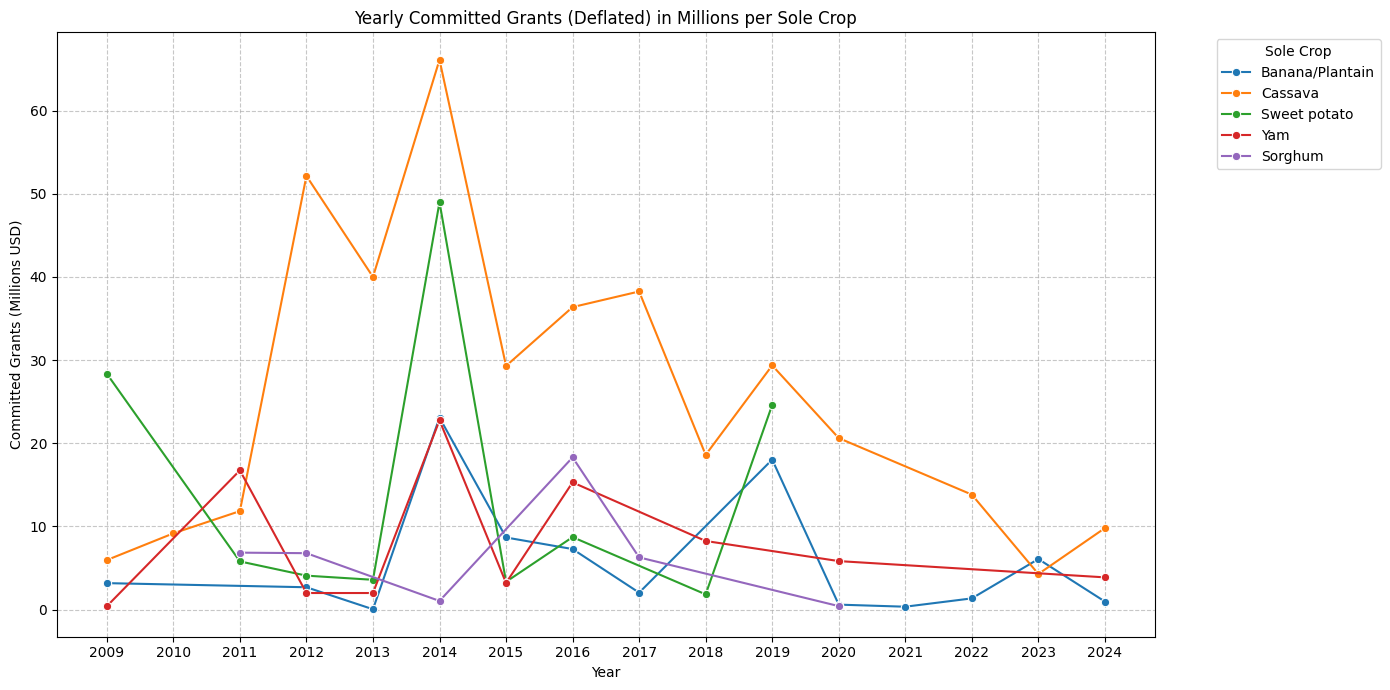

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out rows where 'sole_crop' is None
df_filtered = df[df['sole_crop'].notna()].copy()

# Group by 'year' and 'sole_crop' and sum 'usd_commitment_defl'
yearly_grants = df_filtered.groupby(['year', 'sole_crop'])['usd_commitment_defl'].sum().reset_index()

# 'usd_commitment_defl' is already in millions, so no division needed
yearly_grants['usd_commitment_defl_millions'] = yearly_grants['usd_commitment_defl']

# Plotting the time series
plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_grants, x='year', y='usd_commitment_defl_millions', hue='sole_crop', marker='o')

plt.title('Yearly Committed Grants (Deflated) in Millions per Sole Crop')
plt.xlabel('Year')
plt.ylabel('Committed Grants (Millions USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_grants['year'].unique()) # Ensure all years are shown on x-axis
plt.legend(title='Sole Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

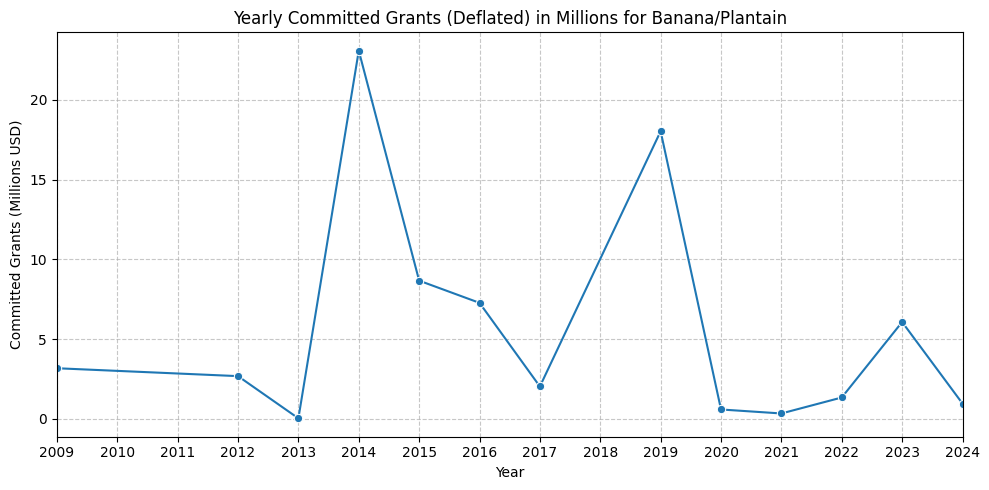

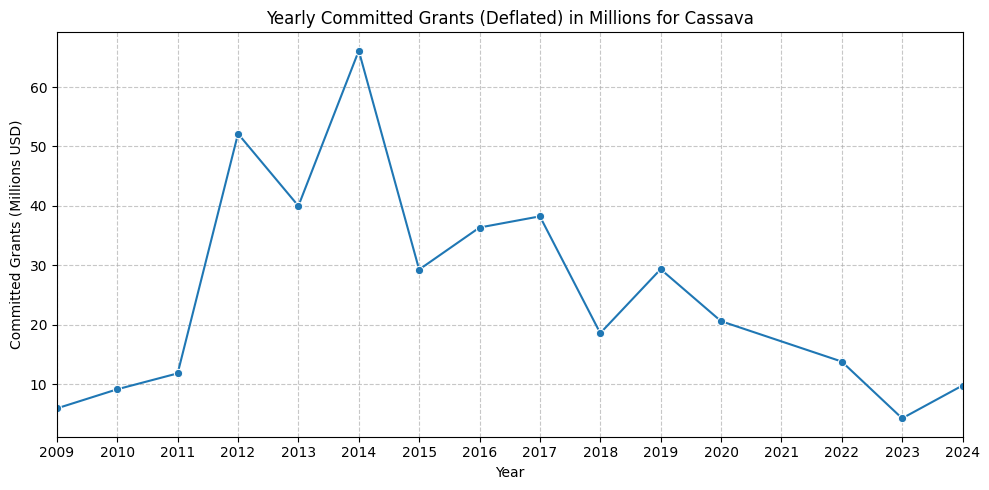

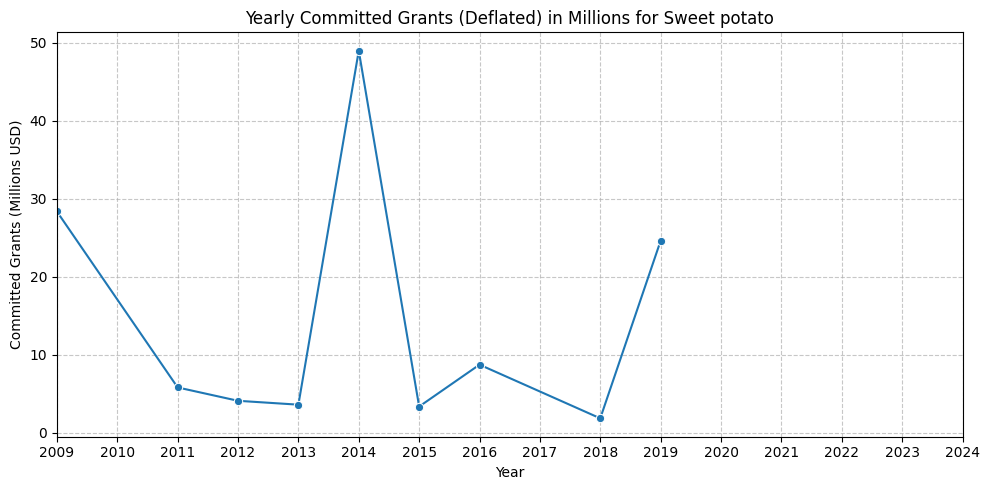

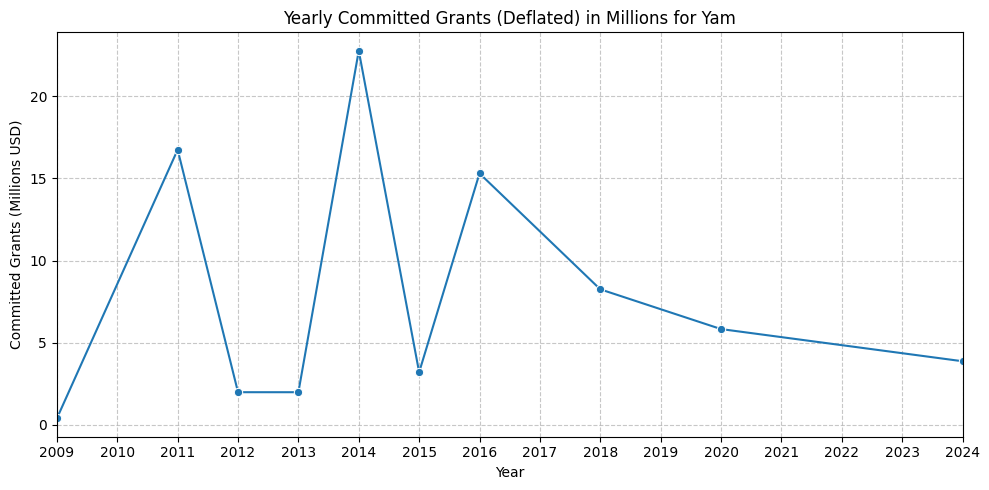

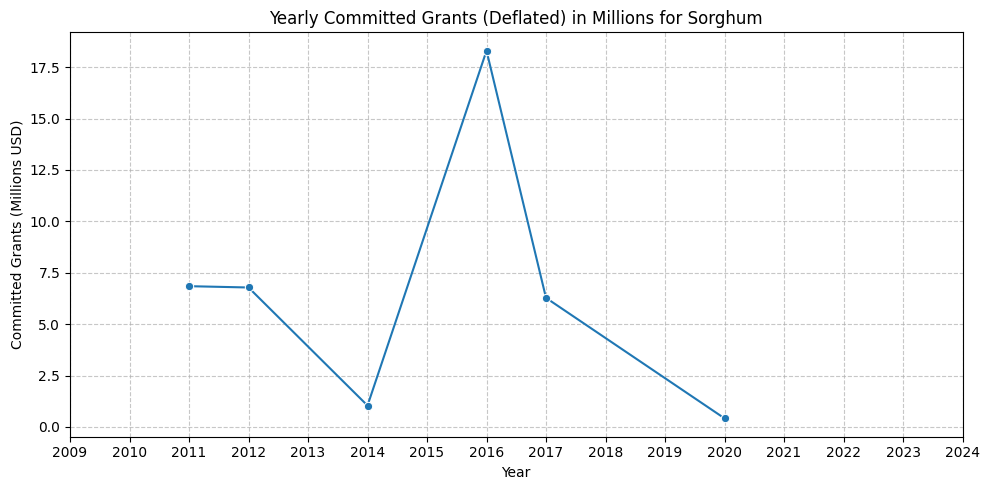

In [56]:
unique_sole_crops = yearly_grants['sole_crop'].unique()

# Define the full range of years to be displayed
all_years = range(2009, 2025) # 2009 to 2024 inclusive

for crop in unique_sole_crops:
    plt.figure(figsize=(10, 5))
    crop_data = yearly_grants[yearly_grants['sole_crop'] == crop]
    sns.lineplot(data=crop_data, x='year', y='usd_commitment_defl_millions', marker='o')
    plt.title(f'Yearly Committed Grants (Deflated) in Millions for {crop}')
    plt.xlabel('Year')
    plt.ylabel('Committed Grants (Millions USD)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(all_years) # Set x-ticks to the full range of years
    plt.xlim(min(all_years), max(all_years)) # Set x-axis limits to the full range
    plt.tight_layout()
    plt.show()

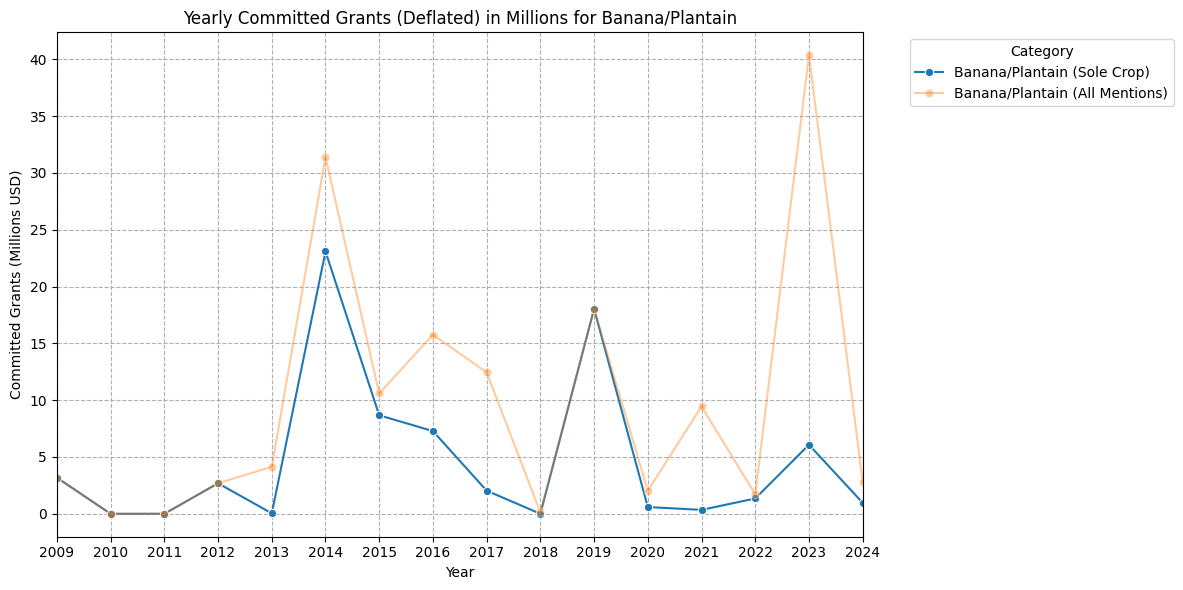

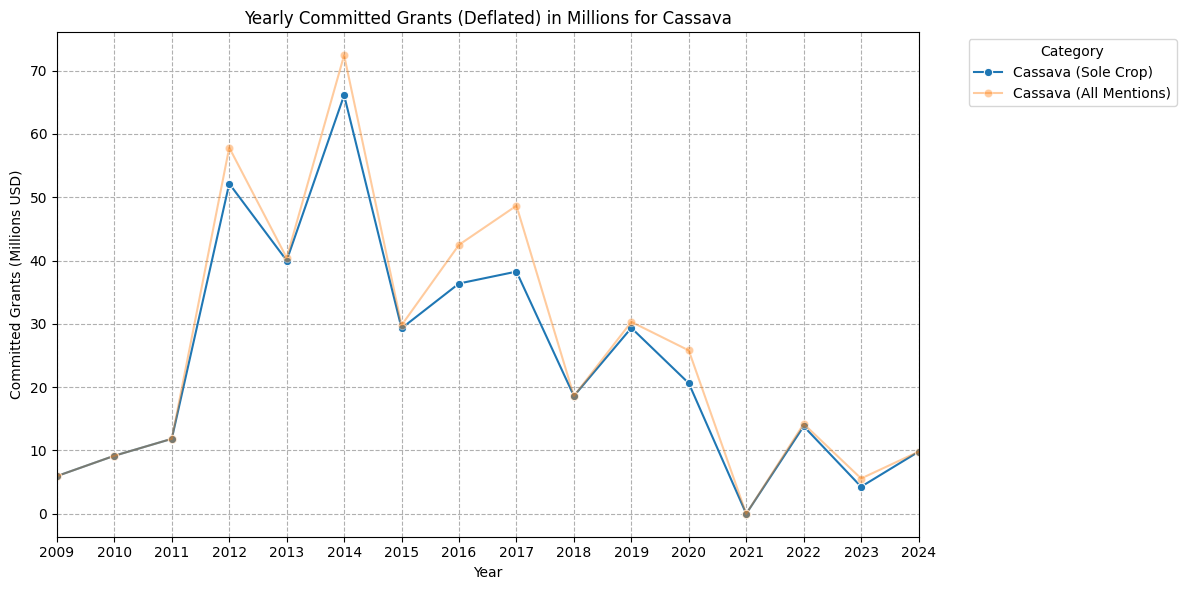

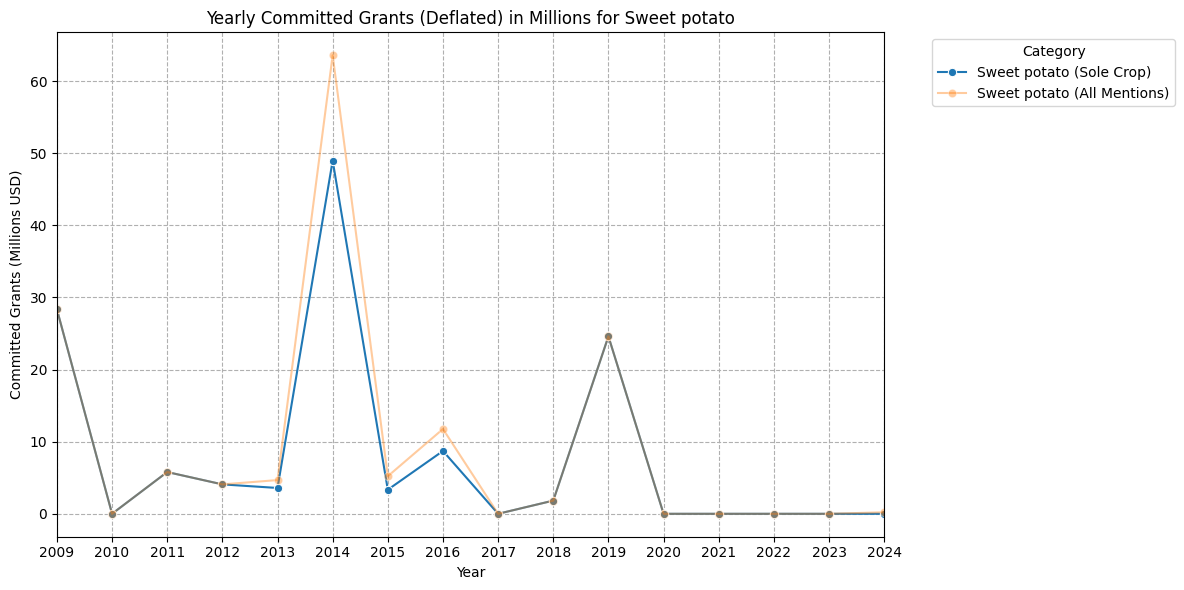

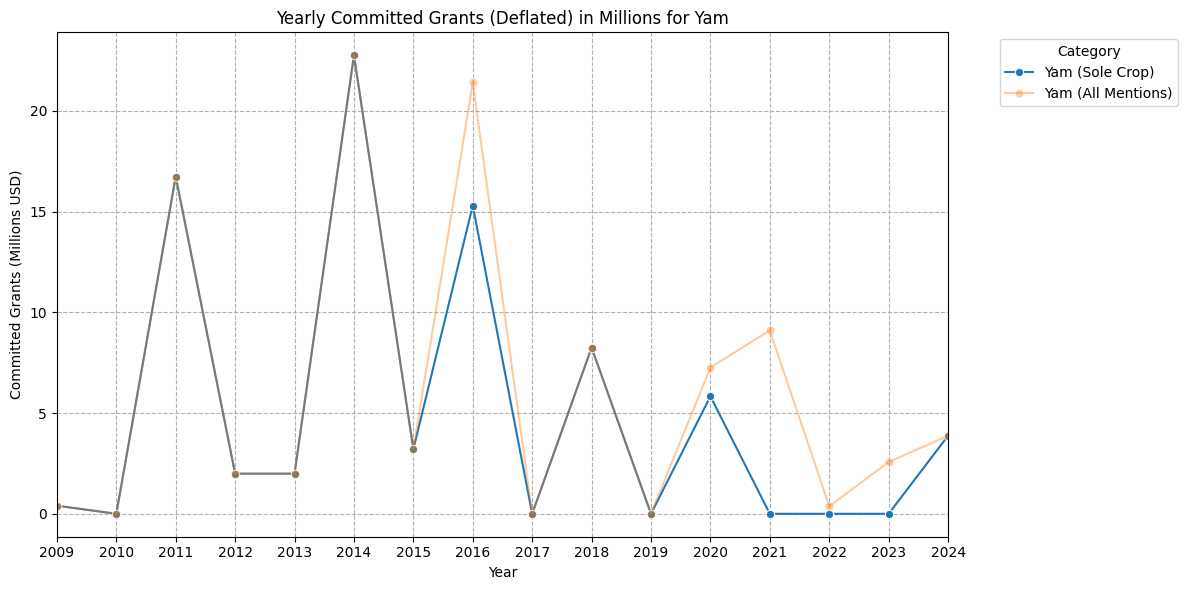

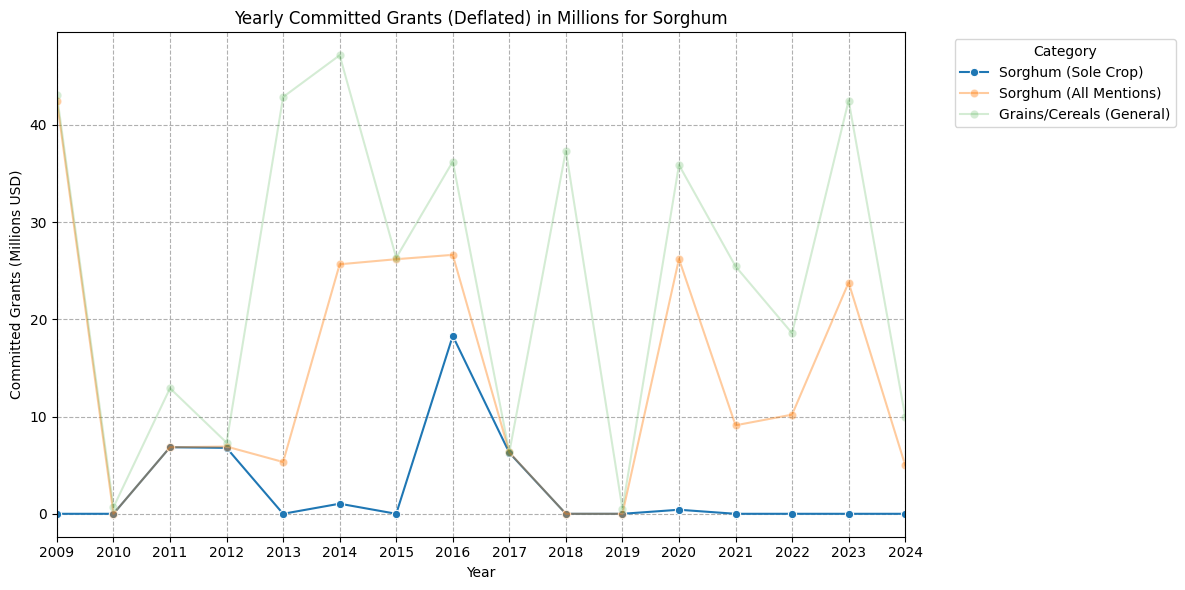

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the full range of years to be displayed
all_years = range(2009, 2025) # 2009 to 2024 inclusive

unique_sole_crops = yearly_grants['sole_crop'].unique()

for i, crop in enumerate(unique_sole_crops):
    fig = plt.figure(figsize=(12, 6))

    # Data for the 'Sole Crop' line
    sole_crop_data = yearly_grants[yearly_grants['sole_crop'] == crop].copy()
    sole_crop_data['Category'] = f'{crop} (Sole Crop)'

    # Data for the 'All Inclusive' line and potential third line for Sorghum
    all_inclusive_df_for_current_crop = pd.DataFrame()
    general_grains_cereals_df = pd.DataFrame() # New DataFrame for the third line for Sorghum

    if crop == 'Banana/Plantain':
        # Projects mentioning 'Banana' OR 'Plantain' (All Mentions for Banana/Plantain)
        temp_df = df[df['combined_agri_products'].apply(lambda x: 'Banana' in x or 'Plantain' in x)].copy()
        all_inclusive_df_for_current_crop = temp_df.groupby('year')['usd_commitment_defl'].sum().reset_index()
    elif crop == 'Cassava':
        # Projects mentioning 'Cassava' OR 'Roots, Tubers & Bananas (RTB)' (All Mentions for Cassava)
        temp_df = df[df['combined_agri_products'].apply(lambda x: 'Cassava' in x or 'Roots, Tubers & Bananas (RTB)' in x)].copy()
        all_inclusive_df_for_current_crop = temp_df.groupby('year')['usd_commitment_defl'].sum().reset_index()
    elif crop == 'Sweet potato':
        # Projects mentioning 'Sweet potato' OR 'Potato' (All Mentions for Sweet potato)
        temp_df = df[df['combined_agri_products'].apply(lambda x: 'Sweet potato' in x or 'Potato' in x)].copy()
        all_inclusive_df_for_current_crop = temp_df.groupby('year')['usd_commitment_defl'].sum().reset_index()
    elif crop == 'Sorghum':
        # 'Sorghum (All Mentions)' - projects specifically mentioning Sorghum
        # This set of projects already inherently includes those where Sorghum is the sole crop.
        temp_df_sorghum_all = df[df['combined_agri_products'].apply(lambda x: 'Sorghum' in x)].copy()
        all_inclusive_df_for_current_crop = temp_df_sorghum_all.groupby('year')['usd_commitment_defl'].sum().reset_index()
        # 'usd_commitment_defl' is already in millions, so no division needed
        all_inclusive_df_for_current_crop['usd_commitment_defl_millions'] = all_inclusive_df_for_current_crop['usd_commitment_defl']
        all_inclusive_df_for_current_crop['Category'] = f'{crop} (All Mentions)'

        # 'Grains/Cereals (General)' for Sorghum - projects based on cumulative definition:
        # (Sole + Inclusive) + Broader Categories
        # This is equivalent to (All Mentions for Sorghum) + (Broader Categories)
        broader_sorghum_categories_filter_list = [
            ('Cereals', 'Honey/Apiculture'),
            ('Wholegrains',),
            ('Grains (general)', 'Wholegrains'),
            ('Cereals', 'Sweet potato'),
            ('Grains (general)', 'Winter melon'),
            ('Cereals', 'Nutri-cereals'),
            ('Grains (general)',),
            ('Cereals',),
            ('Cereals', 'Grain legumes'),
            ('Cereals', 'Grain legumes', 'Grains (general)'),
            ('Grain legumes', 'Grains (general)')
        ]

        # Projects matching the specific broader categories
        broader_category_projects = df[df['combined_agri_products'].apply(tuple).isin(broader_sorghum_categories_filter_list)]

        # Combine 'Sorghum (All Mentions)' projects and 'Broader Categories' projects
        # Use concat and drop_duplicates to get the union of projects based on 'crs_id'
        combined_projects_for_general_grains = pd.concat([temp_df_sorghum_all, broader_category_projects]).drop_duplicates(subset=['crs_id'])

        general_grains_cereals_df = combined_projects_for_general_grains.groupby('year')['usd_commitment_defl'].sum().reset_index()
        # 'usd_commitment_defl' is already in millions, so no division needed
        general_grains_cereals_df['usd_commitment_defl_millions'] = general_grains_cereals_df['usd_commitment_defl']
        general_grains_cereals_df['Category'] = 'Grains/Cereals (General)'
    else:
        # For other crops, projects mentioning the crop itself (All Mentions for other crops)
        temp_df = df[df['combined_agri_products'].apply(lambda x: crop in x)].copy()
        all_inclusive_df_for_current_crop = temp_df.groupby('year')['usd_commitment_defl'].sum().reset_index()

    # 'usd_commitment_defl' is already in millions, so no division needed here either
    if 'usd_commitment_defl_millions' not in all_inclusive_df_for_current_crop.columns and not all_inclusive_df_for_current_crop.empty:
        all_inclusive_df_for_current_crop['usd_commitment_defl_millions'] = all_inclusive_df_for_current_crop['usd_commitment_defl']
        all_inclusive_df_for_current_crop['Category'] = f'{crop} (All Mentions)' # Ensure category is set here too

    # Combine data for plotting
    plot_data_list = [sole_crop_data[['year', 'usd_commitment_defl_millions', 'Category']]]
    if not all_inclusive_df_for_current_crop.empty:
        plot_data_list.append(all_inclusive_df_for_current_crop[['year', 'usd_commitment_defl_millions', 'Category']])
    if not general_grains_cereals_df.empty: # Only add if it's Sorghum and data exists
        plot_data_list.append(general_grains_cereals_df[['year', 'usd_commitment_defl_millions', 'Category']])

    plot_data = pd.concat(plot_data_list)

    # Create a DataFrame with all years for each category and merge to fill missing years with 0
    full_year_df = pd.DataFrame({'year': all_years})
    full_year_df['key'] = 1
    categories_df = pd.DataFrame({'Category': plot_data['Category'].unique()})
    categories_df['key'] = 1
    # Use a Cartesian product to get all combinations of years and categories
    complete_index = pd.merge(full_year_df, categories_df, on='key').drop('key', axis=1)

    plot_data_filled = pd.merge(complete_index, plot_data, on=['year', 'Category'], how='left')
    plot_data_filled['usd_commitment_defl_millions'] = plot_data_filled['usd_commitment_defl_millions'].fillna(0)

    # Define alpha values for each category
    alpha_map = {
        f'{crop} (Sole Crop)': 1.0,
        f'{crop} (All Mentions)': 0.4,
        'Grains/Cereals (General)': 0.2
    }

    # Plot each category separately to control alpha
    for category in plot_data_filled['Category'].unique():
        subset = plot_data_filled[plot_data_filled['Category'] == category]
        sns.lineplot(
            data=subset,
            x='year',
            y='usd_commitment_defl_millions',
            label=category, # Use label for individual legends
            marker='o',
            alpha=alpha_map.get(category, 1.0) # Get alpha from map, default to 1.0
        )

    plt.title(f'Yearly Committed Grants (Deflated) in Millions for {crop}')
    plt.xlabel('Year')
    plt.ylabel('Committed Grants (Millions USD)')
    plt.grid(True, linestyle='--', alpha=1)
    plt.xticks(all_years) # Set x-ticks to the full range of years
    plt.xlim(min(all_years), max(all_years)) # Set x-axis limits to the full range
    plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [58]:
df['long_description'].nunique()

223

In [73]:
df.to_csv('processed_df.csv', index=False)
print('DataFrame df saved to processed_df.csv')

DataFrame df saved to processed_df.csv


In [59]:
unique_long_descriptions_df = pd.DataFrame(df['long_description'].unique(), columns=['long_description'])
unique_long_descriptions_df.to_csv('unique_long_descriptions.csv', index=False)
print('Unique long descriptions saved to unique_long_descriptions.csv')

Unique long descriptions saved to unique_long_descriptions.csv


In [60]:
media_articles_df = pd.read_csv('/content/sample_data/annual_crop_counts (2).csv')
display(media_articles_df.head())
media_articles_df.info()

,Year,Crop,Count
0,2000,cassava,9
1,2000,sorghum,7
2,2000,sweet potato,11
3,2000,yam,3
4,2001,banana/plantain,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Year    124 non-null    int64 
 1   Crop    124 non-null    object
 2   Count   124 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 3.0+ KB


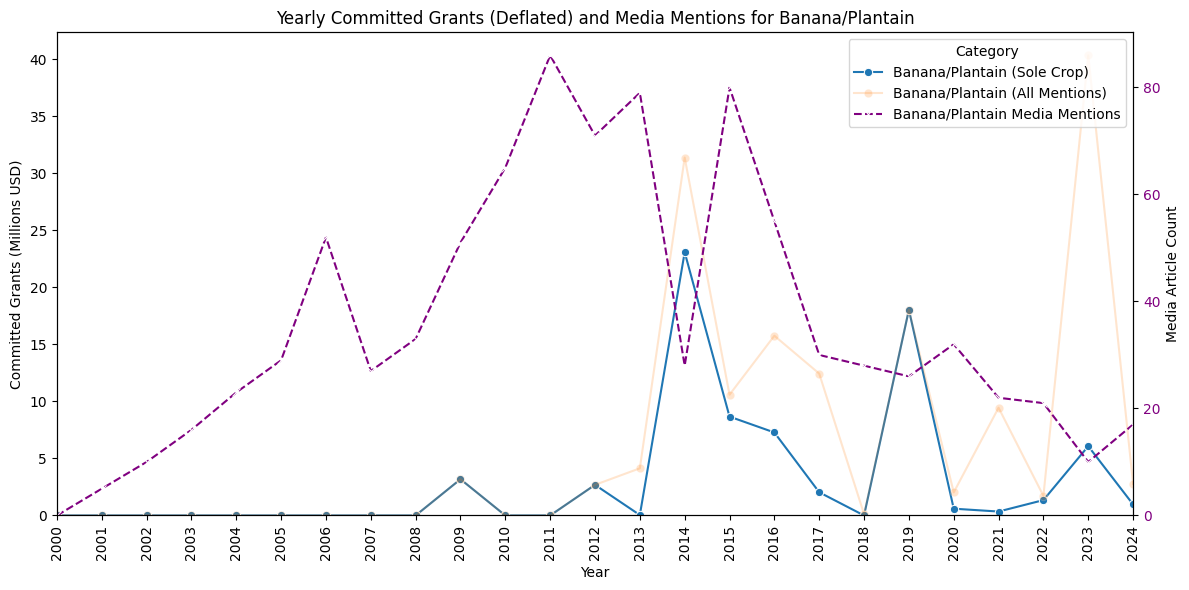

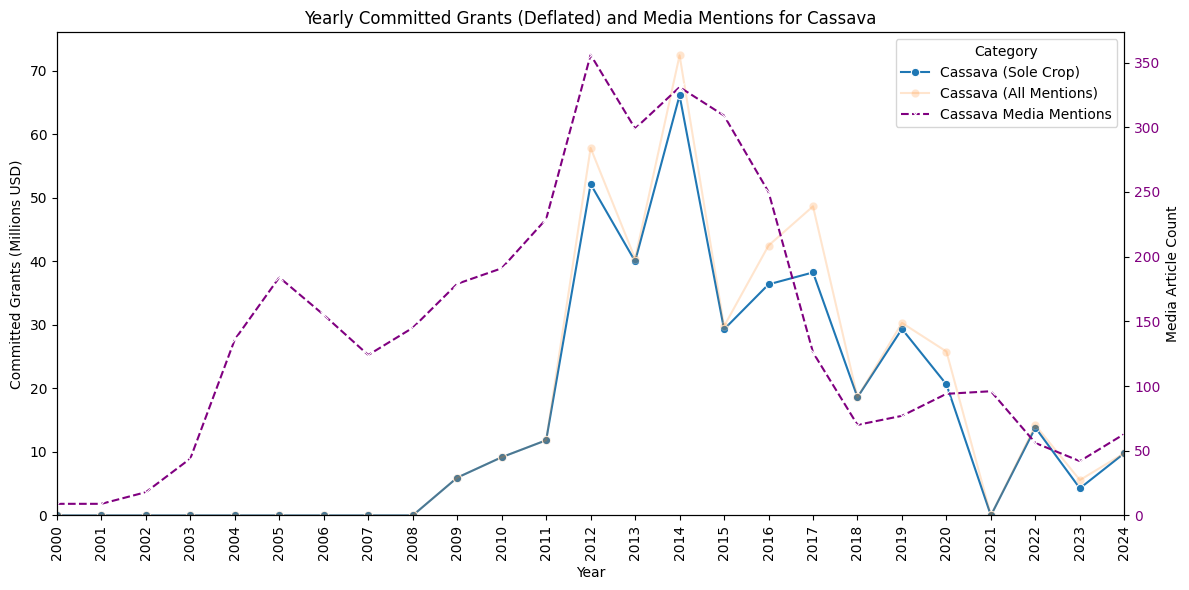

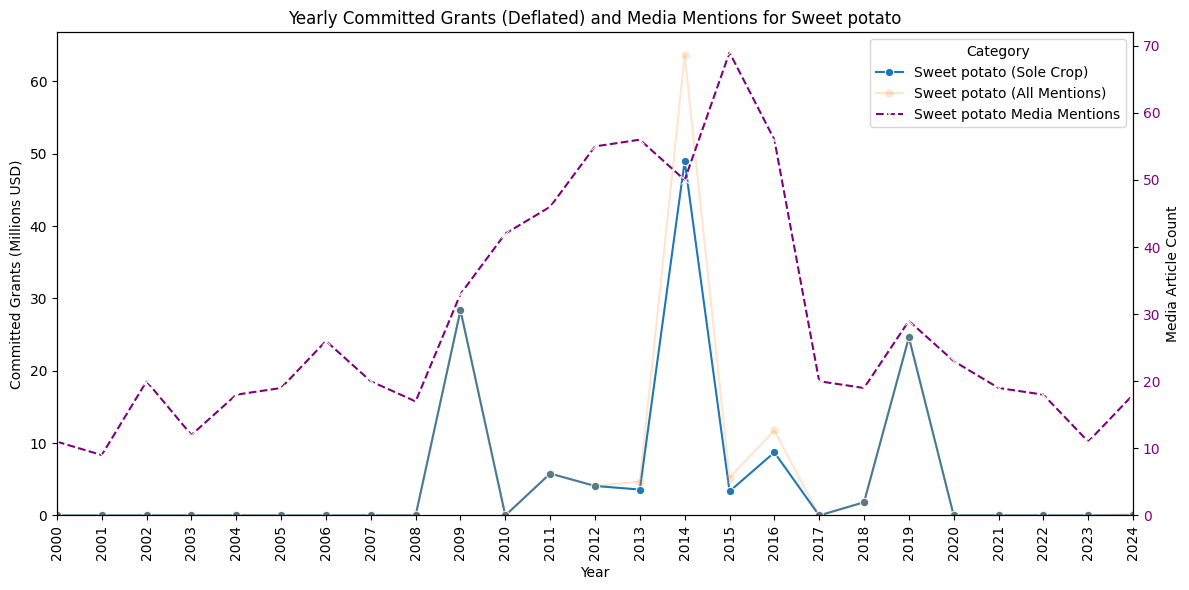

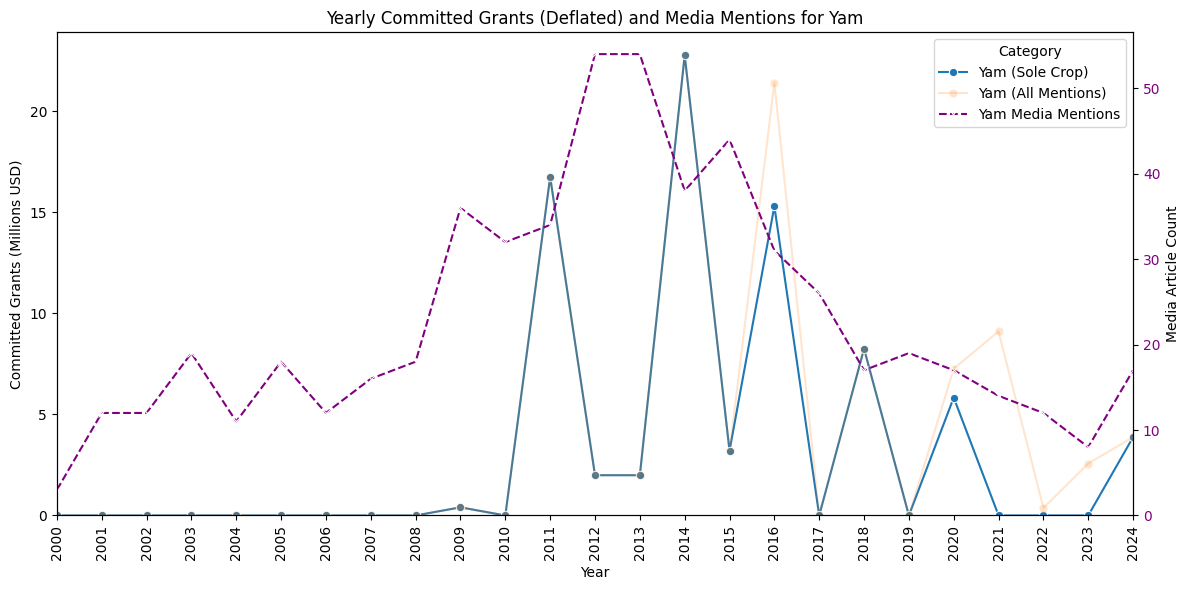

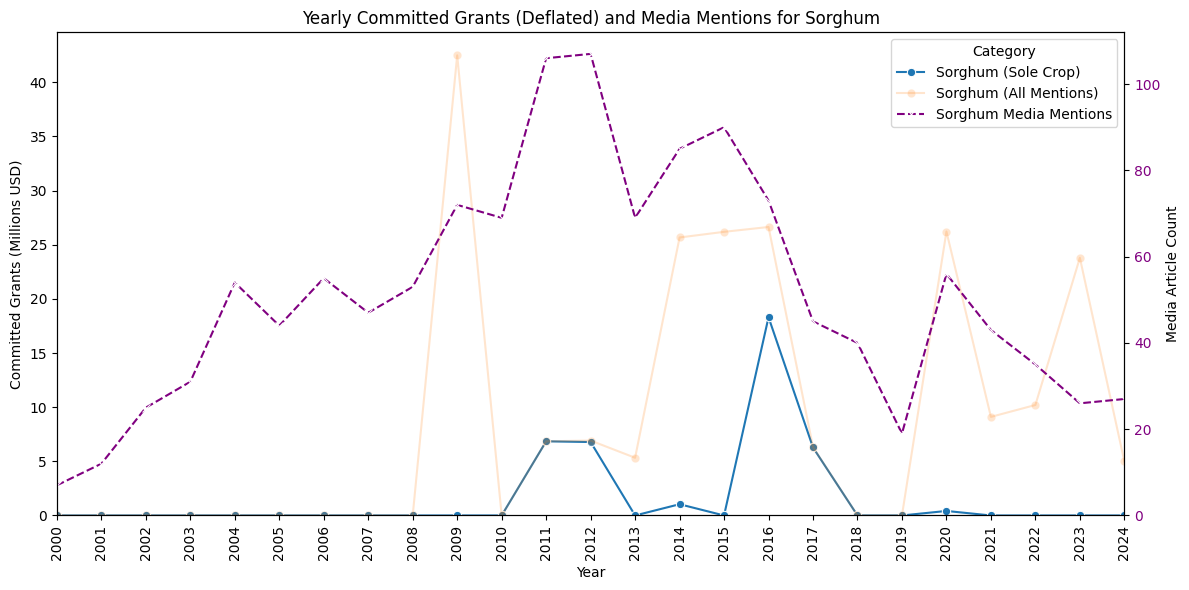

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume yearly_grants, df, unique_sole_crops, and all_years are already defined from previous cells.

# --- START: Prepare media_articles_df for overlay ---
# Standardize crop names in media_articles_df to match sole_crop names
media_articles_df_processed = media_articles_df.copy()
crop_name_standardization_map = {
    'cassava': 'Cassava',
    'sorghum': 'Sorghum',
    'sweet potato': 'Sweet potato',
    'yam': 'Yam',
    'banana/plantain': 'Banana/Plantain'
}
media_articles_df_processed['Crop'] = media_articles_df_processed['Crop'].map(crop_name_standardization_map)

# Filter for crops that are actually in unique_sole_crops (the ones we are plotting grants for)
media_articles_df_processed = media_articles_df_processed[media_articles_df_processed['Crop'].isin(unique_sole_crops)]

# Rename 'Count' to 'media_article_count' for clarity
media_articles_df_processed = media_articles_df_processed.rename(columns={'Count': 'media_article_count'})

# Ensure 'Year' column is integer type
media_articles_df_processed['Year'] = media_articles_df_processed['Year'].astype(int)

# Group by 'Year' and 'Crop' to get yearly counts (if not already aggregated)
yearly_media_articles = media_articles_df_processed.groupby(['Year', 'Crop'])['media_article_count'].sum().reset_index()
yearly_media_articles = yearly_media_articles.rename(columns={'Year': 'year', 'Crop': 'sole_crop'})
# --- END: Prepare media_articles_df for overlay ---

# Define the full range of years to be displayed, from 2000 to 2024 inclusive
all_years = range(2000, 2025)

for i, crop in enumerate(unique_sole_crops):
    fig, ax1 = plt.subplots(figsize=(12, 6)) # Create figure and primary axis for grants

    # Data for the 'Sole Crop' line
    sole_crop_data = yearly_grants[yearly_grants['sole_crop'] == crop].copy()
    sole_crop_data['Category'] = f'{crop} (Sole Crop)'

    # Data for the 'All Inclusive' line and potential third line for Sorghum
    all_inclusive_df_for_current_crop = pd.DataFrame()
    general_grains_cereals_df = pd.DataFrame() # New DataFrame for the third line for Sorghum

    if crop == 'Banana/Plantain':
        temp_df = df[df['combined_agri_products'].apply(lambda x: 'Banana' in x or 'Plantain' in x)].copy()
        all_inclusive_df_for_current_crop = temp_df.groupby('year')['usd_commitment_defl'].sum().reset_index()
    elif crop == 'Cassava':
        temp_df = df[df['combined_agri_products'].apply(lambda x: 'Cassava' in x or 'Roots, Tubers & Bananas (RTB)' in x)].copy()
        all_inclusive_df_for_current_crop = temp_df.groupby('year')['usd_commitment_defl'].sum().reset_index()
    elif crop == 'Sweet potato':
        temp_df = df[df['combined_agri_products'].apply(lambda x: 'Sweet potato' in x or 'Potato' in x)].copy()
        all_inclusive_df_for_current_crop = temp_df.groupby('year')['usd_commitment_defl'].sum().reset_index()
    elif crop == 'Sorghum':
        temp_df_sorghum_all = df[df['combined_agri_products'].apply(lambda x: 'Sorghum' in x)].copy()
        all_inclusive_df_for_current_crop = temp_df_sorghum_all.groupby('year')['usd_commitment_defl'].sum().reset_index()
        all_inclusive_df_for_current_crop['usd_commitment_defl_millions'] = all_inclusive_df_for_current_crop['usd_commitment_defl']
        all_inclusive_df_for_current_crop['Category'] = f'{crop} (All Mentions)'

        broader_sorghum_categories_filter_list = [
            ('Cereals', 'Honey/Apiculture'), ('Wholegrains',), ('Grains (general)', 'Wholegrains'),
            ('Cereals', 'Sweet potato'), ('Grains (general)', 'Winter melon'), ('Cereals', 'Nutri-cereals'),
            ('Grains (general)',), ('Cereals',), ('Cereals', 'Grain legumes'),
            ('Cereals', 'Grain legumes', 'Grains (general)'), ('Grain legumes', 'Grains (general)')
        ]
        broader_category_projects = df[df['combined_agri_products'].apply(tuple).isin(broader_sorghum_categories_filter_list)]
        combined_projects_for_general_grains = pd.concat([temp_df_sorghum_all, broader_category_projects]).drop_duplicates(subset=['crs_id'])
        general_grains_cereals_df = combined_projects_for_general_grains.groupby('year')['usd_commitment_defl'].sum().reset_index()
        general_grains_cereals_df['usd_commitment_defl_millions'] = general_grains_cereals_df['usd_commitment_defl']
        general_grains_cereals_df['Category'] = 'Grains/Cereals (General)'
    else:
        temp_df = df[df['combined_agri_products'].apply(lambda x: crop in x)].copy()
        all_inclusive_df_for_current_crop = temp_df.groupby('year')['usd_commitment_defl'].sum().reset_index()

    if 'usd_commitment_defl_millions' not in all_inclusive_df_for_current_crop.columns and not all_inclusive_df_for_current_crop.empty:
        all_inclusive_df_for_current_crop['usd_commitment_defl_millions'] = all_inclusive_df_for_current_crop['usd_commitment_defl']
        all_inclusive_df_for_current_crop['Category'] = f'{crop} (All Mentions)'

    current_plot_data_list = [sole_crop_data[['year', 'usd_commitment_defl_millions', 'Category']]]
    if not all_inclusive_df_for_current_crop.empty:
        current_plot_data_list.append(all_inclusive_df_for_current_crop[['year', 'usd_commitment_defl_millions', 'Category']])

    current_alpha_map = {
        f'{crop} (Sole Crop)': 1.0,
        f'{crop} (All Mentions)': 0.2
    }

    # if crop == 'Sorghum' and not general_grains_cereals_df.empty:
    #     current_plot_data_list.append(general_grains_cereals_df[['year', 'usd_commitment_defl_millions', 'Category']])
    #     current_alpha_map['Grains/Cereals (General)'] = 0.2

    plot_data = pd.concat(current_plot_data_list)

    full_year_df = pd.DataFrame({'year': all_years})
    full_year_df['key'] = 1
    categories_df = pd.DataFrame({'Category': plot_data['Category'].unique()})
    categories_df['key'] = 1
    complete_index = pd.merge(full_year_df, categories_df, on='key').drop('key', axis=1)

    plot_data_filled = pd.merge(complete_index, plot_data, on=['year', 'Category'], how='left')
    plot_data_filled['usd_commitment_defl_millions'] = plot_data_filled['usd_commitment_defl_millions'].fillna(0)

    # Plot each grant category separately on ax1
    for category in plot_data_filled['Category'].unique():
        sns.lineplot(
            data=plot_data_filled[plot_data_filled['Category'] == category],
            x='year',
            y='usd_commitment_defl_millions',
            label=category,
            marker='o',
            alpha=current_alpha_map.get(category, 1.0),
            ax=ax1,
            legend=False # Disable individual legends
        )

    ax1.set_title(f'Yearly Committed Grants (Deflated) and Media Mentions for {crop}')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Committed Grants (Millions USD)')
    ax1.grid(False) # Make grid invisible
    ax1.set_xticks(all_years)
    ax1.set_xlim(min(all_years), max(all_years))
    ax1.set_ylim(bottom=0) # Ensure y-axis starts at 0
    ax1.tick_params(axis='x', rotation=90) # Rotate x-axis labels

    # --- Plot Media Articles on Secondary Y-axis ---
    ax2 = ax1.twinx() # Create a secondary y-axis

    media_data_for_crop = yearly_media_articles[yearly_media_articles['sole_crop'] == crop]

    # Merge with full_year_df to ensure all years are present, filling missing counts with 0
    media_data_for_crop_filled = pd.merge(full_year_df[['year']], media_data_for_crop, on='year', how='left')
    media_data_for_crop_filled['media_article_count'] = media_data_for_crop_filled['media_article_count'].fillna(0)

    sns.lineplot(
        data=media_data_for_crop_filled,
        x='year',
        y='media_article_count',
        label=f'{crop} Media Mentions',
        marker='x',
        color='purple',
        linestyle='--',
        ax=ax2,
        legend=False # Disable individual legends
    )
    ax2.set_ylabel('Media Article Count')
    ax2.set_ylim(bottom=0) # Ensure y-axis starts at 0
    ax2.tick_params(axis='y', labelcolor='purple') # Color secondary y-axis ticks and label

    # Combine legends from both axes and place inside the plot area
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, title='Category', loc='best') # Moved inside

    plt.tight_layout() # No rect adjustment needed for internal legend
    plt.show()